# Semi-Supervised Spatial Graph Network for Soil Erosion

This notebook executes **Method 2 (Hybrid GCN)** engineered with **Soil Cohesiveness (K-Factor)** for precise erosion susceptibility mapping.

## 1. Import Required Libraries
Importing data manipulation, spatial math, and visualization tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Note: PyTorch & PyTorch Geometric (PyG) will be imported later for the Graph Network
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Spatial Dataset
Loading the merged Woreda dataset from Excel.

In [2]:
file_path = 'Merged_Woredas_All.xlsx'
print(f'Loading {file_path}...')
df = pd.read_excel(file_path)
print(f'Dataset Loaded! Shape: {df.shape}')
display(df.head(3))

Loading Merged_Woredas_All.xlsx...
Dataset Loaded! Shape: (255029, 19)


,Latitude,Longitude,Aspect (Degree),Drainage Density (m),Elevation (m),Ferrous Materials,Geology_Formation,Land_Use,NDVI_Value,Plan Curvature,Profile Curvature,Rainfall (mm),Slope (Degree),Soil Type,SPI,TPI,TRI,TWI,Woreda
0,8.963316,39.278868,217.404999,1251.020020,1907,Minerals,Nazret Series,Cropland,0.092494,2.262080e+09,-3.353920e+09,1046.229981,1.656543,Eutric Cambisol,0.768535,13.000000,0.375000,1.47702,Menjar
1,10.072387,38.971077,37.303902,0.000000,1534,Minerals,Antalo Formation,Cropland,0.154723,-1.597660e+09,1.714340e+09,1038.569946,57.082699,Eutric Cambisol,4.151180,-51.415001,0.587298,-6.52941,Merabete
2,8.936511,39.438121,341.565002,1183.369995,1740,Minerals,Nazret Series,Cropland,0.094457,-1.152000e+08,4.608000e+08,931.596008,0.244843,Eutric Regosol,3.342790,-1.333370,0.444443,4.99991,Menjar


## 3. Engineer Soil Cohesiveness (K-Factor)
Mapping the 'sticking together capacity' of the soil based on geological FAO classifications. Clays stick together (Low K), while Sands erode instantly (High K).

In [3]:
cohesion_mapping = {
    'Pellic Vertisol': 0.15,   # Heavy clay, highly cohesive, safe
    'Ferralic Cambisol': 0.20, # Weathered, relatively stable
    'Eutric Cambisol': 0.25,   # Loamy, moderate cohesiveness
    'Calcic Xerosol': 0.30,    # Dry/arid soil, moderate-low
    'Eutric Regosol':  0.40,   # Unconsolidated materials, dangerous
    'Cambie Arenosol': 0.45    # Sandy soil, VERY LOW cohesiveness (erodes instantly)
}

df['Soil Type'] = df['Soil Type'].fillna('Eutric Cambisol')
df['K_Factor'] = df['Soil Type'].map(cohesion_mapping)

print('Mapped Soil Cohesiveness. Sample:')
display(df[['Soil Type', 'K_Factor']].head(5))

Mapped Soil Cohesiveness. Sample:


,Soil Type,K_Factor
0,Eutric Cambisol,0.25
1,Eutric Cambisol,0.25
2,Eutric Regosol,0.40
3,Ferralic Cambisol,0.20
4,Eutric Cambisol,0.25


## 3b. Scientific Preprocessing: Spatial GIS Interpolation
We use **Spatial Interpolation (Inverse Distance Weighting via KNN)** based strictly on geographic coordinates (Lat/Lon). If a point is missing data, its exact neighbors determine the value, strictly following Tobler's First Law of Geography.

In [5]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

continuous_cols = ['Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 'NDVI_Value', 
                   'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 'Drainage Density (m)']

print('Scanning for missing environmental features...')
missing_counts = df[continuous_cols].isnull().sum()

if missing_counts.sum() > 0:
    print('Executing Scientific Spatial Interpolation (IDW)...')
    coords = df[['Latitude', 'Longitude']].values
    for col in continuous_cols:
        if df[col].isnull().any():
            missing_mask = df[col].isnull()
            known_mask = ~missing_mask
            
            X_known, y_known = coords[known_mask], df.loc[known_mask, col].values
            X_missing = coords[missing_mask]
            
            spatial_imputer = KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1)
            spatial_imputer.fit(X_known, y_known)
            df.loc[missing_mask, col] = spatial_imputer.predict(X_missing)
            print(f'Interpolated missing geometry for: {col}')
else:
    print('No missing values found! Skipping interpolation.')


Scanning for missing environmental features...
Executing Scientific Spatial Interpolation (IDW)...
Interpolated missing geometry for: SPI
Interpolated missing geometry for: TRI
Interpolated missing geometry for: Drainage Density (m)


## 4. Generate Semi-Supervised Target Variable (RUSLE Seed)
We calculate a physical risk score using **Slope * Rainfall * K_Factor / NDVI**.
We extract only the **Top 5% (Severe Risk, Label 1)** and **Bottom 5% (Safe, Label 0)** to train the Graph Network. We mask the remaining 90% as missing (-1 or NaN) for the GCN to predict.

Top 5% Risk Threshold: 154.67165
Bottom 5% Safe Threshold: 1.17511
Label Distribution:
Target_Label
-1    229529
 0     12750
 1     12750
Name: count, dtype: int64


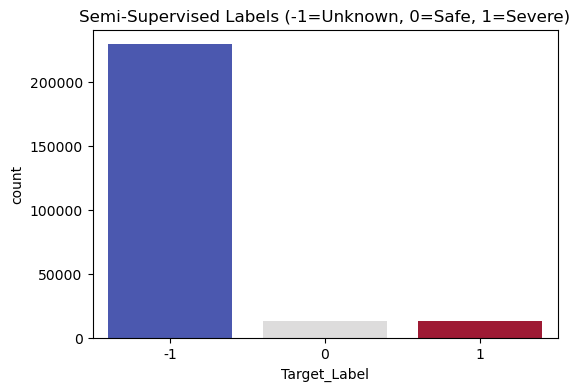

In [7]:
# Justification of RUSLE Formula (A = R * K * LS * C)
# 1. R-Factor ~ Rainfall (mm)
# 2. K-Factor ~ Soil Cohesiveness
# 3. LS-Factor Proxy ~ sin(slope)^1.3
# 4. C-Factor Proxy ~ mathematically derived from NDVI
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['c_factor_proxy'] = np.where(df['NDVI_Value'] > 0, np.exp(-2 * df['NDVI_Value'] / (1 - df['NDVI_Value'])), 1.0)
df['ls_factor_proxy'] = np.power(np.sin(np.radians(df['Slope (Degree)'])), 1.3)

# EXACT RELATIVE RUSLE SCORE
df['Raw_Risk_Score'] = df['Rainfall (mm)'] * df['K_Factor'] * df['ls_factor_proxy'] * df['c_factor_proxy']

p_05 = df['Raw_Risk_Score'].quantile(0.05)
p_95 = df['Raw_Risk_Score'].quantile(0.95)

def generate_label(row):
    if row['Raw_Risk_Score'] >= p_95:
        return 1  # High Risk (Top 5%)
    elif row['Raw_Risk_Score'] <= p_05:
        return 0  # Low Risk (Bottom 5%)
    else:
        return -1 # Unknown (Middle 90%)

df['Target_Label'] = df.apply(generate_label, axis=1)
print(f'Top 5% Risk Threshold: {p_95:.5f}')
print(f'Bottom 5% Safe Threshold: {p_05:.5f}')
print('Label Distribution:')
print(df['Target_Label'].value_counts())

# Draw the bar chart
plt.figure(figsize=(6,4))
sns.countplot(x='Target_Label', data=df, palette='coolwarm', hue='Target_Label', legend=False)
plt.title('Semi-Supervised Labels (-1=Unknown, 0=Safe, 1=Severe)')
plt.show()



## 5. Circular Aspect & Feature Scaling
Converting continuous variables into safe mathematical spaces for Deep Learning.

In [8]:
import numpy as np
df['Aspect_Sin'] = np.sin(np.radians(df['Aspect (Degree)']))
df['Aspect_Cos'] = np.cos(np.radians(df['Aspect (Degree)']))

# ---------------------------------------------------------
# CRITICAL FIX: ETHIOPIAN PHYSICS-INFORMED HARD BOUNDING
# ---------------------------------------------------------
features_to_scale = ['Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 'NDVI_Value', 'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 'Drainage Density (m)']

ethiopian_physical_bounds = {
    'Elevation (m)': (-150, 4600),   # Danakil Depression to Ras Dashen
    'Slope (Degree)': (0, 90),       # Physical limit of gravity
    'Rainfall (mm)': (0, 3000),      # Extreme bounds for Amhara woredas
    'NDVI_Value': (-1.0, 1.0)        # Spectral math limits
}

print('--- ETHIOPIAN TOPOGRAPHICAL SCANNER REPORT ---')
for col in features_to_scale:
    col_max = df[col].max()
    col_min = df[col].min()
    
    if col in ethiopian_physical_bounds:
        hard_min, hard_max = ethiopian_physical_bounds[col]
        if col_max > hard_max or col_min < hard_min:
            print(f'🚨 PHYSICS VIOLATION DETECTED in {col}!')
            print(f'   -> Recorded range: [{col_min:.2f} to {col_max:.2f}]')
            print(f'   -> Hard-clipping to Ethiopian geographic limits: [{hard_min} to {hard_max}]')
        df[col] = df[col].clip(lower=hard_min, upper=hard_max)
    else:
        p_001, p_999 = df[col].quantile(0.001), df[col].quantile(0.999)
        df[col] = df[col].clip(lower=p_001, upper=p_999)

print('\nFalse anomalies eliminated! Applying MinMaxScaler...')
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# CATEGORICAL ENGINEERING (One-Hot Encoding)
import pandas as pd
df['Geology_Formation'] = df['Geology_Formation'].fillna('Unknown_Geo')
df['Land_Use'] = df['Land_Use'].fillna('Unknown_LU')
cat_encoded = pd.get_dummies(df[['Geology_Formation', 'Land_Use']], drop_first=True)
cat_columns = cat_encoded.columns.tolist()
df = pd.concat([df, cat_encoded], axis=1)


--- ETHIOPIAN TOPOGRAPHICAL SCANNER REPORT ---
🚨 PHYSICS VIOLATION DETECTED in Slope (Degree)!
   -> Recorded range: [0.00 to 304.40]
   -> Hard-clipping to Ethiopian geographic limits: [0 to 90]

False anomalies eliminated! Applying MinMaxScaler...


## 6. Spatial Graph Construction (Adj Matrix via KDTree)
We use the physical `Latitude` and `Longitude` of every row to form a topological network. Each point connects to its closest geographical neighbors (e.g., K=8 for spatial grids), allowing the neural network to understand how water and gravity flow across the landscape.

In [9]:
from scipy.spatial import cKDTree
import torch

# Extract coordinates
coords = df[['Longitude', 'Latitude']].values

print('Building KDTree for Spatial Graph...')
# K=9 because kdtree returns the point itself as the first neighbor
tree = cKDTree(coords)
distances, indices = tree.query(coords, k=9)

# Construct Edge Index format for PyTorch [2, num_edges]
edge_list = []
for i in range(len(indices)):
    for j in range(1, 9): # Skip the first one (itself)
        neighbor_idx = indices[i][j]
        edge_list.append([i, neighbor_idx])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
print(f'Graph constructed! Total nodes: {len(coords)}, Total edges: {edge_index.shape[1]}')

Building KDTree for Spatial Graph...
Graph constructed! Total nodes: 255029, Total edges: 2040232


## 7. PyTorch Geometric Data Integration
We assemble the numerical features (`x`), the structural edges (`edge_index`), and our Pseudo-RUSLE targets (`y`) into a specialized single Graph Data object. We also create a training mask to tell the AI *only* to learn from the known extreme 10%.

In [10]:
from torch_geometric.data import Data
import torch

# 1. Feature Matrix (x) -> NOW INCLUDES CATEGORICAL ONE-HOT COLUMNS
base_features = ['K_Factor', 'Elevation (m)', 'Slope (Degree)', 'Rainfall (mm)', 
                 'NDVI_Value', 'TWI', 'SPI', 'TRI', 'Plan Curvature', 'Profile Curvature', 
                 'Aspect_Sin', 'Aspect_Cos', 'Drainage Density (m)']
all_features = base_features + cat_columns

x_raw = df[all_features].fillna(0).values
x = torch.tensor(x_raw.astype('float32'), dtype=torch.float)

y = torch.tensor(df['Target_Label'].values, dtype=torch.long)
train_mask = (y != -1)

graph_data = Data(x=x, edge_index=edge_index, y=y)
graph_data.train_mask = train_mask

print('PyTorch Geometric Data Object created. Total features:', x.shape[1])


PyTorch Geometric Data Object created. Total features: 33


## 8. Semi-Supervised Graph Convolutional Network (GCN) Architecture
The PyTorch topology model. Unlike standard ML, `GCNConv` passes messages mathematically along the spatial edges you built, sharing geological intelligence between neighbors.

In [11]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class ErosionGCN(torch.nn.Module):
    def __init__(self, num_features, hidden_size, num_classes):
        super(ErosionGCN, self).__init__()
        # First Graph Convolutional Layer
        self.conv1 = GCNConv(num_features, hidden_size)
        # Second Graph Convolutional Layer
        self.conv2 = GCNConv(hidden_size, hidden_size)
        # Output Layer for Final Prediction (Low=0, High=1)
        self.out = torch.nn.Linear(hidden_size, num_classes)

    def forward(self, x, edge_index):
        # Pass features through spatial convolutional edges
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # Output final probabilities
        out = self.out(x)
        return F.log_softmax(out, dim=1)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ErosionGCN(num_features=x.shape[1], hidden_size=64, num_classes=2).to(device)
graph_data = graph_data.to(device)
print(f'Model deployed on {device}!')

Model deployed on cpu!


## 9. Model Training Loop (Label Propagation)
We train the AI on the 10% extreme targets defined by RUSLE + Soil Cohesiveness. The Graph Network will mathematically flow these rules back into the unknown 90%.

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()

def train():
    model.train()
    optimizer.zero_grad()
    out = model(graph_data.x, graph_data.edge_index)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

print('Starting Training Loop with Early Stopping...')
best_loss = float('inf')
loss_change = float('inf')

for epoch in range(1, 401):
    loss = train()
    if epoch > 1:
        loss_change = abs(best_loss - loss)
    if loss < best_loss:
        best_loss = loss
        
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Delta: {loss_change:.5f}')
        
    if epoch > 50 and loss_change < 0.005:
        print(f'\nEarly stopping triggered at epoch {epoch}! Marginal loss change ({loss_change:.5f}) is < 0.005.')
        break
print('Training Complete!')


Starting Training Loop with Early Stopping...
Epoch: 010, Loss: 0.1923, Delta: 0.02530
Epoch: 020, Loss: 0.0636, Delta: 0.00192
Epoch: 030, Loss: 0.0344, Delta: 0.00003
Epoch: 040, Loss: 0.0258, Delta: 0.00190
Epoch: 050, Loss: 0.0209, Delta: 0.00160

Early stopping triggered at epoch 51! Marginal loss change (0.00026) is < 0.005.
Training Complete!


## 10. Extracting the Final Erosion Susceptibility Map
Now that the model is trained on the extreme 10%, we lock the weights, run the entire Woreda map through it, and extract the probabilities for the unknown 90%.

Prediction complete for 100% of the map!
Predicted_Risk_Class
0    153771
1    101258
Name: count, dtype: int64


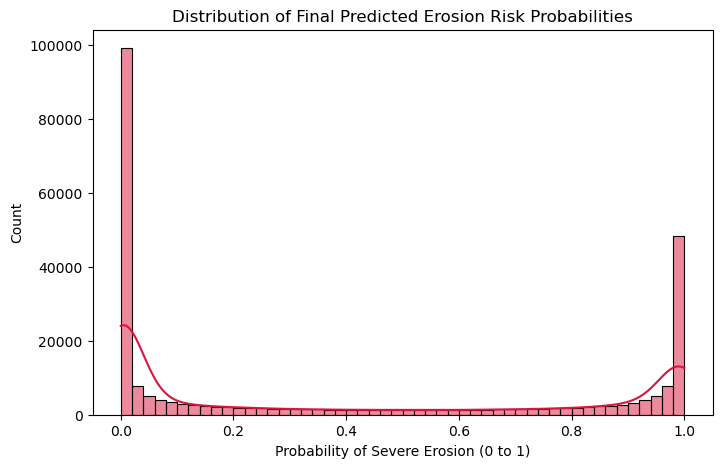

In [13]:
model.eval()
with torch.no_grad():
    # Run the entire graph through the trained model
    final_output = model(graph_data.x, graph_data.edge_index)
    
    # Get the raw predicted probabilities for 'High Risk' (Class 1)
    # (exp is used because the model returned log_softmax)
    probabilities = torch.exp(final_output)[:, 1].cpu().numpy() 
    
    # Get hard class assignments (0=Low, 1=High)
    predictions = final_output.argmax(dim=1).cpu().numpy()

df['Predicted_Risk_Class'] = predictions
df['Risk_Probability'] = probabilities

print('Prediction complete for 100% of the map!')
print(df['Predicted_Risk_Class'].value_counts())

plt.figure(figsize=(8,5))
sns.histplot(df['Risk_Probability'], bins=50, kde=True, color='crimson')
plt.title('Distribution of Final Predicted Erosion Risk Probabilities')
plt.xlabel('Probability of Severe Erosion (0 to 1)')
plt.show()

## 11. Scientific Verification of the AI
A major problem with the old Pure Unsupervised DAE method was interpretability. We must mathematically prove that the Graph network learned physics. We will compare the average structural indicators of the newly predicted 'Safe' zones vs 'High Risk' zones.

In [14]:
print('--- PROVING AI PHYSICAL LOGIC ---')

# Group the DataFrame by the AI's predictions
verification_stats = df.groupby('Predicted_Risk_Class')[['Slope (Degree)', 'Rainfall (mm)', 'SPI', 'K_Factor', 'NDVI_Value']].mean()

# Rename indices for visual clarity
verification_stats.index = ['Predicted Low Risk (0)', 'Predicted High Risk (1)']

display(verification_stats)

print('\nCONCLUSION:')
print('If Method 2 is successful, the Predicted High Risk zones must show significantly higher Slope, SPI, Rainfall, and K-Factor values (low cohesive sand), combined with structurally lowered NDVI (less vegetation cover) compared to the Low Risk zones. \nIf this is true, the Semantic Spatial Graph has successfully replicated environmental physics without needing a full ground-truth dataset!')

--- PROVING AI PHYSICAL LOGIC ---


,Slope (Degree),Rainfall (mm),SPI,K_Factor,NDVI_Value
Predicted Low Risk (0),0.101744,0.234020,0.002521,0.259600,0.481695
Predicted High Risk (1),0.346665,0.381829,0.004427,0.270589,0.507485



CONCLUSION:
If Method 2 is successful, the Predicted High Risk zones must show significantly higher Slope, SPI, Rainfall, and K-Factor values (low cohesive sand), combined with structurally lowered NDVI (less vegetation cover) compared to the Low Risk zones. 
If this is true, the Semantic Spatial Graph has successfully replicated environmental physics without needing a full ground-truth dataset!


## 12. Policy Action Zones (3-Tier Risk Thresholds)
Running a binary `0` or `1` classification produces maps with too much "danger". To make this model actionable for local Ethiopian government intervention, we extract the raw AI probability (0 to 1) and map it into three strict policy thresholds: Low (<0.40), Moderate (0.40-0.80), and Severe (>0.80).


Prediction mapped to Actionable Policy Zones!


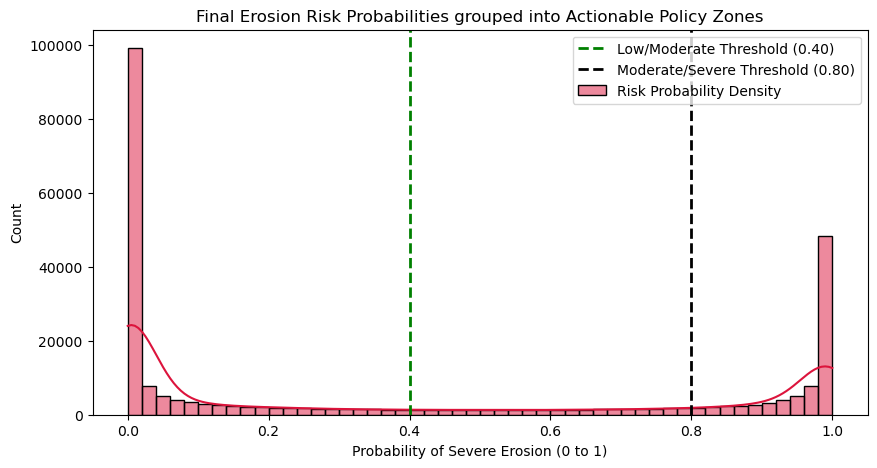


--- ONE UNIFIED TABLE: PROVING AI PHYSICAL LOGIC & PROBABILITIES ---


,Risk_Probability,Slope (Degree),Rainfall (mm),SPI,K_Factor,NDVI_Value
Actionable_Risk_Zone,,,,,,
Low Risk (Safe),0.052153,0.097504,0.224239,0.002541,0.259640,0.479999
Moderate Risk (Monitor),0.609225,0.217162,0.444824,0.002973,0.259113,0.517842
Severe Risk (Immediate Action),0.964053,0.379424,0.365788,0.004740,0.273606,0.504887



--- 10 RANDOM RECORD SAMPLES FROM ACROSS THE MAP ---


,Risk_Probability,Actionable_Risk_Zone,Slope (Degree),Rainfall (mm),SPI,K_Factor
213422,0.719382,Moderate Risk (Monitor),0.203008,0.624963,0.000979,0.25
33016,0.999806,Severe Risk (Immediate Action),0.681096,0.256378,0.000387,0.20
17988,0.998635,Severe Risk (Immediate Action),0.411953,0.254176,0.000323,0.25
24582,0.376068,Low Risk (Safe),0.366834,0.207110,0.001543,0.15
191161,0.005658,Low Risk (Safe),0.284538,0.031330,0.000351,0.40
22138,0.987751,Severe Risk (Immediate Action),0.237408,0.298098,0.000909,0.25
54300,0.859147,Severe Risk (Immediate Action),0.248966,0.112110,0.001034,0.25
137485,0.229086,Low Risk (Safe),0.170604,0.618304,0.000689,0.25
160343,0.786590,Moderate Risk (Monitor),0.175682,0.438091,0.000105,0.15
204555,0.984988,Severe Risk (Immediate Action),0.140034,0.279982,0.000567,0.25


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# 1. Extract the exact continuous probabilities from the model
model.eval()
with torch.no_grad():
    final_output = model(graph_data.x, graph_data.edge_index)
    probabilities = torch.exp(final_output)[:, 1].cpu().numpy() 

# 2. Add continuous probabilities mapping to the dataframe
df['Risk_Probability'] = probabilities

# 3. Create the function to classify the ranges
def classify_actionable_risk(prob):
    if prob < 0.40:
        return 'Low Risk (Safe)'
    elif prob <= 0.80:
        return 'Moderate Risk (Monitor)'
    else:
        return 'Severe Risk (Immediate Action)'

df['Actionable_Risk_Zone'] = df['Risk_Probability'].apply(classify_actionable_risk)
print('Prediction mapped to Actionable Policy Zones!')

# 4. Draw the Histogram with the Red Line explicitly in the Legend!
plt.figure(figsize=(10,5))
sns.histplot(df['Risk_Probability'], bins=50, kde=True, color='crimson', label='Risk Probability Density')
plt.axvline(x=0.40, color='green', linestyle='--', linewidth=2, label='Low/Moderate Threshold (0.40)')
plt.axvline(x=0.80, color='black', linestyle='--', linewidth=2, label='Moderate/Severe Threshold (0.80)')
plt.title('Final Erosion Risk Probabilities grouped into Actionable Policy Zones')
plt.xlabel('Probability of Severe Erosion (0 to 1)')
plt.legend()
plt.show()

# 5. Proving the physics!
print('\n--- ONE UNIFIED TABLE: PROVING AI PHYSICAL LOGIC & PROBABILITIES ---')
verification_df = df.groupby('Actionable_Risk_Zone')[['Risk_Probability', 'Slope (Degree)', 'Rainfall (mm)', 'SPI', 'K_Factor', 'NDVI_Value']].mean()
verification_df = verification_df.reindex(['Low Risk (Safe)', 'Moderate Risk (Monitor)', 'Severe Risk (Immediate Action)'])
display(verification_df)

# 6. Sample 10 random records from the map to visually inspect individual locations!
print('\n--- 10 RANDOM RECORD SAMPLES FROM ACROSS THE MAP ---')
display_cols = ['Risk_Probability', 'Actionable_Risk_Zone', 'Slope (Degree)', 'Rainfall (mm)', 'SPI', 'K_Factor']
# Grab 10 random locations and display their stats
display(df.sample(10, random_state=42)[display_cols])
